# Week 8：K-Means 聚类与 K 值选择

目标：理解 K-Means 如何把未标注样本分组，并用 inertia、silhouette score 与业务知识选择合适的聚类数量。

## 1. K-Means 的循环

先指定要分成 K 组，然后不断重复两步：

1. **Assignment（分配）**：每个样本分给距离最近的中心。
2. **Update（更新）**：每组所有样本取平均，作为新的中心。

它希望让每个样本离自己所属中心的平方距离总和尽量小：

$$
\text{inertia} = \sum_{i=1}^{n} \lVert x_i - \mu_{c_i} \rVert^2
$$

这里 `mu_c_i` 是样本 `x_i` 所属簇的中心。更新步骤为什么取平均：因为平均值恰好能使一组样本到中心的平方距离总和最小。这个结论理解即可，不要求本节手推。

## 2. 两个重要提醒

- K-Means 基于距离，因此各特征通常必须先标准化。
- K-Means 给出的只是簇编号 0、1、2；编号没有“类别名称”含义，标签只能在训练后用于解释和评估。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
dataset = load_iris(as_frame=True)
X = dataset.data
y = dataset.target  # K-Means 训练时不会使用它。

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'样本数：{X.shape[0]}，特征数：{X.shape[1]}')
print('真实物种名称：', list(dataset.target_names))

样本数：150，特征数：4
真实物种名称： ['setosa', 'versicolor', 'virginica']


In [3]:
results = []
for k in range(2, 9):
    # n_init=20：从 20 组不同初始中心出发，保留 inertia 最小的一次，减少随机初始化影响。
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    cluster_labels = model.fit_predict(X_scaled)
    results.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette_score': silhouette_score(X_scaled, cluster_labels),
    })

k_results = pd.DataFrame(results)
display(k_results)

,k,inertia,silhouette_score
0,2,222.361705,0.581750
1,3,139.820496,0.459948
2,4,114.092328,0.384471
3,5,90.807592,0.345511
4,6,80.022188,0.322037
5,7,71.033431,0.327694
6,8,62.514940,0.341744


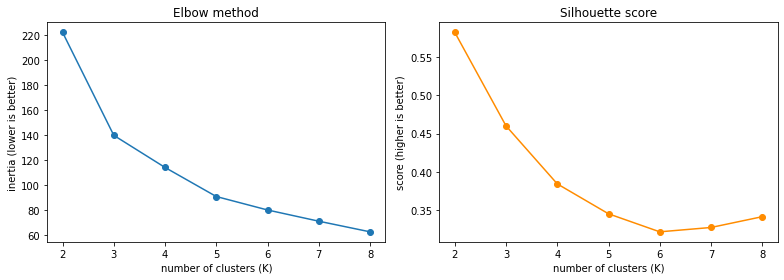

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_results['k'], k_results['inertia'], marker='o')
axes[0].set(title='Elbow method', xlabel='number of clusters (K)', ylabel='inertia (lower is better)')

axes[1].plot(k_results['k'], k_results['silhouette_score'], marker='o', color='darkorange')
axes[1].set(title='Silhouette score', xlabel='number of clusters (K)', ylabel='score (higher is better)')
plt.tight_layout()
plt.show()

## 3. 怎么选择 K

- inertia 一定会随 K 增大而下降，因此不能简单选最小值；观察曲线何处开始变平，这称为 **elbow（肘部）**。
- silhouette score 越高，通常表示同簇更紧密、不同簇更分开。
- 两个分数只是辅助；最终还要考虑业务是否需要、能够解释几个群体。


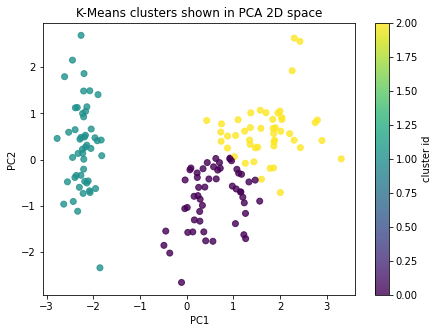

cluster id,0,1,2
true species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


In [5]:
# 本例为观察方便选择 K=3；注意这个选择没有在训练时读取 y。
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 仅为可视化，把 4 维数据投到二维；PCA 也不读取 y。
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='viridis', alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means clusters shown in PCA 2D space')
plt.colorbar(label='cluster id')
plt.show()

# 训练结束后，才用真实标签帮助解释各簇大致包含什么。
cluster_table = pd.crosstab(
    pd.Series(y, name='true species').map(dict(enumerate(dataset.target_names))),
    pd.Series(clusters, name='cluster id'),
)
display(cluster_table)

## 4. 聚类不等于分类

即使本数据恰好有三个真实物种，也不能预设 K-Means 的三个簇一定一一对应三个物种。K-Means 只根据几何距离分组；真实类别可能形状不规则、彼此重叠，或根本不符合“近似圆形簇”的假设。

思考题：为什么 K-Means 得到的 cluster id 不能直接当作真实类别名称？